In [ ]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F 
import torch.optim as optim
import torch.utils.data as data 
from torch.nn import TripletMarginLoss
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torch_geometric as thg 
from torch_geometric.nn import GAT, GraphConv, SAGEConv, SAGPooling, GraphNorm, global_mean_pool, GINEConv
from torch_geometric.data import Batch, Data
from torch_geometric.loader import DataLoader


import os 
import cv2 
import h5py
import numpy as np 
from tqdm import tqdm 
import matplotlib.pyplot as plt
from sklearn.neighbors import KDTree
import networkx as nx
from mpl_toolkits.mplot3d import Axes3D
import random 
from sklearn.model_selection import train_test_split


In [20]:
PATH = "Dataset.hdf5"

In [21]:
files = h5py.File(PATH, "r")
xdataset = np.array(files["X_jets"])
m0  = np.array(files["m0"])
pt = np.array(files["pt"])
ydataset = np.array(files["y"])

In [22]:
def standard_scale(data):
    
    # Min-Max Scaling to [0, 1]
    min_val = np.min(data)
    max_val = np.max(data)
    scaled_data = (data - min_val) / (max_val - min_val)
    
    return scaled_data

In [23]:
xdataset[:, :, :, 0] = standard_scale(np.sqrt(np.sqrt(xdataset[:, :, :, 0])))
xdataset[:, :, :, 1] = standard_scale(xdataset[:, :, :, 1])
xdataset[:, :, :, 2] = standard_scale(xdataset[:, :, :, 2])


m0 = standard_scale(m0)
pt = standard_scale(pt)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..134.72449].


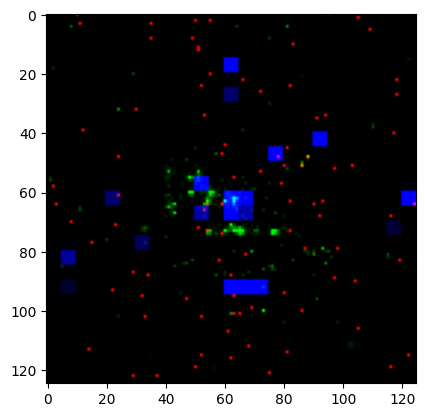

In [24]:
plt.imshow(xdataset[0] * 1000)

In [ ]:


def extract_points_from_image(image, label, m0, pt):
    threshold = max(0.01, np.mean(image[image > 0]) * 0.1)
    points = np.argwhere(image > threshold)
    intensities = image[points[:, 0], points[:, 1]]
    z_coords = intensities  # Z from intensity
    return np.column_stack((points, z_coords, np.full(len(points), label), 
                            np.full(len(points), m0), np.full(len(points), pt))) if len(points) > 0 else np.empty((0, 6))

def enrich_features_with_density_and_track(xy_coords, track_img):
    spatial_tree = KDTree(xy_coords)
    neighbors = spatial_tree.query_radius(xy_coords, r=3.0)
    densities = np.array([len(n) for n in neighbors])

    track_points = np.argwhere(track_img > 0)
    if len(track_points) == 0:
        track_distances = np.full(len(xy_coords), 50.0)
    else:
        track_tree = KDTree(track_points)
        track_distances, _ = track_tree.query(xy_coords, k=1)

    return densities, track_distances

def point_cloud_to_graph_3d_radius(ecal_points, hcal_points, track_img):
    if len(ecal_points) == 0 and len(hcal_points) == 0:
        return nx.Graph(), np.empty((0, 6)), np.empty((0, 3))

    all_nodes = np.vstack([ecal_points, hcal_points]) if ecal_points.size and hcal_points.size else ecal_points if ecal_points.size else hcal_points
    all_nodes[:, 2] /= np.max(all_nodes[:, 2]) if np.max(all_nodes[:, 2]) > 0 else 1

    densities, track_dists = enrich_features_with_density_and_track(all_nodes[:, [0, 1]], track_img)
    avg_track_intensity = np.mean(track_img[track_img > 0]) if np.any(track_img > 0) else 0.1
    radius_3d = avg_track_intensity * 100.0

    G = nx.Graph()
    for i, p in enumerate(all_nodes):
        G.add_node(i, intensity=p[2], x=(p[0]/62.5) - 1, y=(p[1]/62.5) - 1, z=p[2],
                   is_ecal=(p[3] == -1), is_hcal=(p[3] == 1),
                   m0=p[4], pt=p[5],
                   density=densities[i], track_dist=track_dists[i])

    kdtree = KDTree(all_nodes[:, :3])
    indices = kdtree.query_radius(all_nodes[:, :3], r=radius_3d)
    for i, neighbors in enumerate(indices):
        for j in neighbors:
            if i != j:
                dist = np.linalg.norm(all_nodes[i, :3] - all_nodes[j, :3])
                weight = np.exp(-dist / 5)
                G.add_edge(i, j, weight=weight)

    # Restore track-to-node edge logic
    track_points = np.argwhere(track_img > 0)
    if len(track_points) > 0:
        track_tree = KDTree(track_points)
        distances, indices = track_tree.query(all_nodes[:, :2], k=1)
        threshold = 5.0  # Set connection distance threshold
        for node_id, (dist, t_idx) in enumerate(zip(distances, indices)):
            if dist[0] < threshold:
                track_node_id = len(all_nodes) + t_idx[0]
                if not G.has_node(track_node_id):
                    G.add_node(track_node_id, intensity=0, 
                               x=(track_points[t_idx[0]][0]/62.5)-1, 
                               y=(track_points[t_idx[0]][1]/62.5)-1, z=0.05,
                               is_ecal=False, is_hcal=False,
                               m0=0, pt=0, density=0, track_dist=0)
                G.add_edge(node_id, track_node_id, weight=np.exp(-dist[0]/5))

    return G, all_nodes, track_points

def convert_to_pyg_graph(graph):
    if len(graph) == 0:
        return None

    node_features = np.array([[attrs['intensity'], attrs['x'], attrs['y'], attrs['z'],
                           attrs['is_ecal'], attrs['is_hcal'], attrs['m0'], 
                           attrs['pt'], 
                           attrs['density'].item() if isinstance(attrs['density'], np.ndarray) else attrs['density'],
                           attrs['track_dist'].item() if isinstance(attrs['track_dist'], np.ndarray) else attrs['track_dist']] 
                          for _, attrs in graph.nodes(data=True)])


    node_mapping = {node: i for i, node in enumerate(graph.nodes())}
    edge_index = torch.tensor([[node_mapping[u], node_mapping[v]] for u, v in graph.edges()], dtype=torch.long).t().contiguous()
    edge_weights = torch.tensor([graph[u][v]['weight'] for u, v in graph.edges()], dtype=torch.float)

    return Data(x=torch.tensor(node_features, dtype=torch.float), edge_index=edge_index, edge_attr=edge_weights)


def process_dataset_for_triplet(xdataset, ydataset, m0_values, pt_values):
    graph_list = {0: [], 1: []}

    for idx, (xdata, ydata) in enumerate(tqdm(zip(xdataset, ydataset), desc="Processing images", total=len(ydataset))):
        ecal_points = extract_points_from_image(xdata[:, :, 0], -1, m0_values[idx], pt_values[idx])
        hcal_points = extract_points_from_image(xdata[:, :, 1], 1, m0_values[idx], pt_values[idx])
        graph, _, _ = point_cloud_to_graph_3d_radius(ecal_points, hcal_points, xdata[:, :, 2])
        if len(graph) == 0:
            continue

        pyg_graph = convert_to_pyg_graph(graph)
        if pyg_graph is None:
            continue

        pyg_graph.y = torch.tensor(ydata.astype(int), dtype=torch.long)
        graph_list[int(ydata)].append(pyg_graph)

    triplet_data = []
    for label in [0, 1]:
        other_label = 1 - label
        if len(graph_list[label]) < 2 or len(graph_list[other_label]) < 1:
            continue
        for anchor in graph_list[label]:
            positive = random.choice(graph_list[label])
            negative = random.choice(graph_list[other_label])
            triplet_data.append((anchor, positive, negative))

    return triplet_data


In [26]:
xyz = 30000
dataset = process_dataset_for_triplet(xdataset[:xyz], ydataset[:xyz], m0[:xyz], pt[:xyz])

Processing images: 100%|██████████| 30000/30000 [00:31<00:00, 950.51it/s]


In [ ]:


# Assuming `graph_dataset` is your list of Data objects
train_data, temp_data = train_test_split(dataset, test_size=0.4, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(f"Train: {len(train_data)}, Validation: {len(val_data)}, Test: {len(test_data)}")


Train: 18000, Validation: 6000, Test: 6000


In [28]:
from torch_geometric.loader import DataLoader

batch_size = 32
from torch_geometric.data import Batch

def contrastive_collate_fn(batch):
    g1_list, g2_list, labels = zip(*batch)
    batch1 = Batch.from_data_list(g1_list)
    batch2 = Batch.from_data_list(g2_list)
    labels = torch.stack(labels)
    return batch1, batch2, labels

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=contrastive_collate_fn)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, collate_fn=contrastive_collate_fn)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=contrastive_collate_fn)


In [ ]:
class GNNBlock(nn.Module):
    def __init__(self, hidden_dim, input_dim=None):
        super(GNNBlock, self).__init__()
        input_dim = hidden_dim if input_dim is None else input_dim

        self.gat1 = GAT(input_dim, hidden_dim * 2, num_layers=2)
        self.nor1 = GraphNorm(hidden_dim * 2)
        self.gat2 = GAT(hidden_dim * 2, hidden_dim * 2, num_layers=2)

        self.sage1 = SAGEConv(input_dim, hidden_dim * 2)
        self.nor2 = GraphNorm(hidden_dim * 2)
        self.sage2 = SAGEConv(hidden_dim * 2, hidden_dim * 2)

        self.graphconv1 = GraphConv(input_dim, hidden_dim * 2)
        self.nor3 = GraphNorm(hidden_dim * 2)
        self.graphconv2 = GraphConv(hidden_dim * 2, hidden_dim * 2)

        self.gine1 = GINEConv(nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim * 2)
        ), edge_dim=1)
        self.nor4 = GraphNorm(hidden_dim * 2)
        self.gine2 = GINEConv(nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, hidden_dim * 2)
        ), edge_dim=1)

        self.norm1 = GraphNorm(hidden_dim * 8 + input_dim)
        self.norm2 = GraphNorm(hidden_dim * 2)

        self.final = GAT(hidden_dim * 8 + input_dim, hidden_dim * 2, num_layers=2)
        self.residual = GraphConv(input_dim, hidden_dim * 2)
        self.pool1 = SAGPooling(hidden_dim * 2, ratio=0.5)

    def forward(self, x, edge_index, batch, edge_weight=None):
        dense = x
        residual = self.residual(x, edge_index)  # Don't pass edge_weight to GraphConv

        # GAT Branch
        gat_out = F.silu(self.nor1(self.gat1(x, edge_index)))
        gat_out = self.gat2(gat_out, edge_index)

        # GraphSAGE Branch
        sage_out = F.silu(self.nor2(self.sage1(x, edge_index)))
        sage_out = self.sage2(sage_out, edge_index)

        # GINE Branch (reshape edge_weight)
        if edge_weight is not None:
            edge_attr = edge_weight.view(-1, 1)
        else:
            edge_attr = torch.ones((edge_index.size(1), 1), device=x.device)

        gine_out = F.silu(self.nor4(self.gine1(x, edge_index, edge_attr)))
        gine_out = self.gine2(gine_out, edge_index, edge_attr)

        # GraphConv Branch
        graphconv_out = F.silu(self.nor3(self.graphconv1(x, edge_index)))
        graphconv_out = self.graphconv2(graphconv_out, edge_index)

        # Concatenate and Pool
        x = F.silu(self.norm1(torch.cat([gat_out, sage_out, graphconv_out, gine_out, dense], dim=1)))
        x = F.silu(self.norm2(self.final(x, edge_index) + residual))

        x, edge_index, edge_weight, batch, _, _ = self.pool1(x, edge_index, edge_weight, batch)

        return x, edge_index, edge_weight, batch


class GNNModel(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=24, output_dim=256):
        super(GNNModel, self).__init__()
        self.graph1 = GNNBlock(hidden_dim, input_dim)
        self.graph2 = GNNBlock(hidden_dim * 2)
        self.graph3 = GNNBlock(hidden_dim * 4)
        


        self.mlp = nn.Linear(hidden_dim * 8, output_dim)
        self.final_fc = nn.Linear(output_dim, output_dim)

        self.drop = nn.Dropout(0.0)

    def forward(self, data):
        x, e, b = data.x, data.edge_index, data.batch
        edge_weight = data.edge_attr if hasattr(data, 'edge_attr') else None  # Get edge weights if available

        # Pass through GNN blocks
        x, e, edge_weight, b = self.graph1(x, e, b, edge_weight)
        x, e, edge_weight, b = self.graph2(x, e, b, edge_weight)
        x, e, edge_weight, b = self.graph3(x, e, b, edge_weight)


        x = global_mean_pool(x, b)

        # Fully connected layers
        x = F.silu(self.mlp(self.drop(x)))
        return self.final_fc(self.drop(x))

In [34]:
def l2_regularization(model, weight_decay=1e-6, bias_decay=1e-8):
    weight_decay_loss = 0
    bias_decay_loss = 0
    for name, param in model.named_parameters():
        if 'weight' in name:
            weight_decay_loss += torch.norm(param, p=2)  # L2 norm for weights
        elif 'bias' in name:
            bias_decay_loss += torch.norm(param, p=1)  # L2 norm for biases
    return weight_decay * weight_decay_loss + bias_decay * bias_decay_loss


In [ ]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define model, optimizer, scheduler, and loss
model = GNNModel(input_dim=10, hidden_dim=32, output_dim=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)
loss_fn = nn.TripletMarginLoss(margin=1.0)

# Custom collate function for triplet loss (Anchor, Positive, Negative)
def triplet_collate_fn(batch):
    anchors, positives, negatives = zip(*batch)
    anchor_batch = Batch.from_data_list(anchors)
    positive_batch = Batch.from_data_list(positives)
    negative_batch = Batch.from_data_list(negatives)
    return anchor_batch, positive_batch, negative_batch

# Compute accuracy based on triplet distances
def compute_accuracy(anchor, positive, negative):
    pos_dist = torch.norm(anchor - positive, dim=1)
    neg_dist = torch.norm(anchor - negative, dim=1)
    correct = (pos_dist < neg_dist).sum().item()
    return correct, len(anchor)

# Training loop
def train():
    model.train()
    for epoch in range(100):
        total_loss = 0
        total_correct = 0
        total_samples = 0
        train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}")

        for anchor, positive, negative in train_loader_tqdm:
            anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)
            optimizer.zero_grad()

            anchor_out = model(anchor)
            positive_out = model(positive)
            negative_out = model(negative)

            loss = loss_fn(anchor_out, positive_out, negative_out)
            loss += l2_regularization(model)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct, samples = compute_accuracy(anchor_out, positive_out, negative_out)
            total_correct += correct
            total_samples += samples

            train_loader_tqdm.set_postfix(loss=total_loss / (len(train_loader_tqdm) + 1e-6), acc=total_correct / (total_samples + 1e-6))

        val_loss, val_acc = validate()
        scheduler.step(val_loss)
        print(f"Epoch {epoch+1}, Train Loss: {total_loss / len(train_loader):.4f}, Train Acc: {total_correct / total_samples:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")

# Validation loop
def validate():
    model.eval()
    val_loss = 0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        val_loader_tqdm = tqdm(val_loader, desc="Validation")
        for anchor, positive, negative in val_loader_tqdm:
            anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)

            anchor_out = model(anchor)
            positive_out = model(positive)
            negative_out = model(negative)

            loss = loss_fn(anchor_out, positive_out, negative_out)
            val_loss += loss.item()
            correct, samples = compute_accuracy(anchor_out, positive_out, negative_out)
            total_correct += correct
            total_samples += samples

        avg_loss = val_loss / len(val_loader)
        avg_acc = total_correct / total_samples
        print(f"Validation Loss: {avg_loss:.4f}, Validation Accuracy: {avg_acc:.4f}")
        return avg_loss, avg_acc

train()


Validation: 100%|██████████| 188/188 [00:24<00:00,  7.58it/s]


Validation Loss: 0.9944, Validation Accuracy: 0.5085
Epoch 1, Train Loss: 0.9992, Train Acc: 0.5078, LR: 0.000100


Validation: 100%|██████████| 188/188 [00:26<00:00,  7.10it/s]


Validation Loss: 0.9964, Validation Accuracy: 0.5047
Epoch 2, Train Loss: 0.9972, Train Acc: 0.5076, LR: 0.000100


Validation: 100%|██████████| 188/188 [00:26<00:00,  7.05it/s]


...

Validation Loss: 0.8827, Validation Accuracy: 0.5847
Epoch 28, Train Loss: 0.9027, Train Acc: 0.5730, LR: 0.000001


Validation: 100%|██████████| 188/188 [00:22<00:00,  8.18it/s]


Validation Loss: 0.8827, Validation Accuracy: 0.5825
Epoch 29, Train Loss: 0.9018, Train Acc: 0.5698, LR: 0.000001


Epoch 30:  83%|████████▎ | 469/563 [02:10<00:26,  3.58it/s, acc=0.573, loss=0.747]


KeyboardInterrupt: 